In [ ]:
import numpy as np
import matplotlib.pyplot as plt

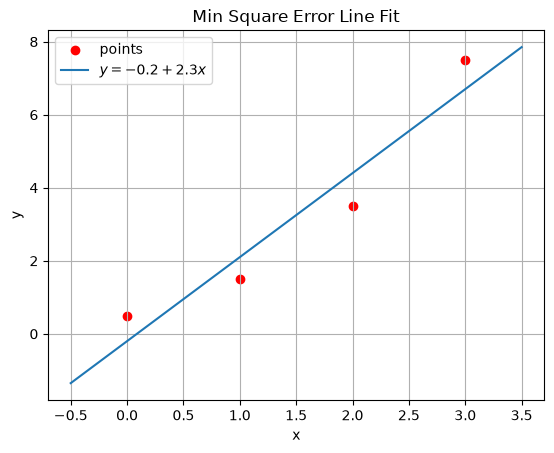

In [ ]:
points = [(0,0.5),(2,3.5),(1,1.5),(3,7.5)]
xs, ys = zip(*points)

y = lambda x : -0.2 + 2.3 * x

x = np.linspace(-0.5, 3.5, 200)

plt.scatter(xs, ys, color="red", label="points")
plt.plot(x, y(x), label="$y = -0.2 + 2.3x$")
plt.title(f"Min Square Error Line Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.savefig(
    "media/line_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

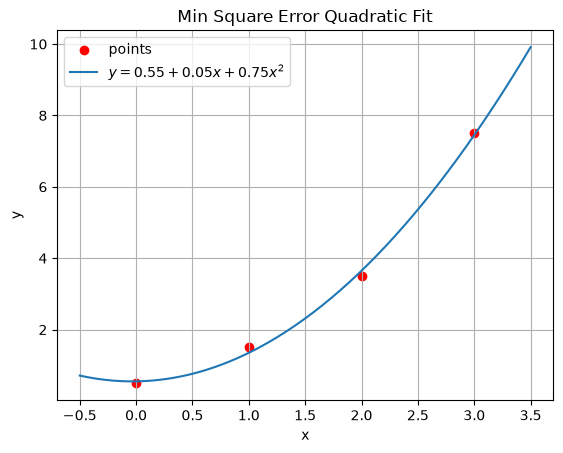

In [ ]:
points = [(0,0.5),(2,3.5),(1,1.5),(3,7.5)]
xs, ys = zip(*points)

y = lambda x : 0.55 + 0.05 * x + 0.75 * x**2

x = np.linspace(-0.5, 3.5, 200)

plt.scatter(xs, ys, color="red", label="points")
plt.plot(x, y(x), label="$y = 0.55 + 0.05x + 0.75x^2$")
plt.title(f"Min Square Error Quadratic Fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True)

plt.savefig(
    "media/quadratic_fit.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [ ]:
def newton_raphson(grad, hess, c0, delta=1.0, tol=1e-7):
    c = np.asarray(c0, float)
    iterations = [{"c": c.copy(), "grad": grad(c), "step": None}]

    J_inv = np.linalg.inv(hess(c))
    c_new = c - delta * J_inv @ grad(c)

    while np.linalg.norm(c_new - c) > tol:
        step = np.linalg.norm(c_new - c)
        c = c_new
        g = grad(c)
        iterations.append({"c": c.copy(), "grad": g, "step": step})
        J_inv = np.linalg.inv(hess(c))
        c_new = c - delta * J_inv @ g

    return c_new, iterations  

In [ ]:
points = [(0,0.5),(2,3.5),(1,1.5),(3,7.5)]

def grad_E(c):
    return np.array([8 * c[0] + 12 * c[1] - 26,
                     12 * c[0] + 28 * c[1] - 62])

def hess_E(c):
    return np.array([[8, 12],
                    [12, 28]], float)

c, iterations = newton_raphson(grad_E, hess_E, c0=[0, 0], delta=0.5)

for it in iterations:
    c = ", ".join(f"{v:.6f}" for v in it["c"])
    g = ", ".join(f"{v:.6f}" for v in it["grad"])
    print(f"c=({c})  grad=({g})")


c=(0.000000, 0.000000)  grad=(-26.000000, -62.000000)
c=(-0.100000, 1.150000)  grad=(-13.000000, -31.000000)
c=(-0.150000, 1.725000)  grad=(-6.500000, -15.500000)
c=(-0.175000, 2.012500)  grad=(-3.250000, -7.750000)
c=(-0.187500, 2.156250)  grad=(-1.625000, -3.875000)
c=(-0.193750, 2.228125)  grad=(-0.812500, -1.937500)
c=(-0.196875, 2.264063)  grad=(-0.406250, -0.968750)
c=(-0.198438, 2.282031)  grad=(-0.203125, -0.484375)
c=(-0.199219, 2.291016)  grad=(-0.101563, -0.242188)
c=(-0.199609, 2.295508)  grad=(-0.050781, -0.121094)
c=(-0.199805, 2.297754)  grad=(-0.025391, -0.060547)
c=(-0.199902, 2.298877)  grad=(-0.012695, -0.030273)
c=(-0.199951, 2.299438)  grad=(-0.006348, -0.015137)
c=(-0.199976, 2.299719)  grad=(-0.003174, -0.007568)
c=(-0.199988, 2.299860)  grad=(-0.001587, -0.003784)
c=(-0.199994, 2.299930)  grad=(-0.000793, -0.001892)
c=(-0.199997, 2.299965)  grad=(-0.000397, -0.000946)
c=(-0.199998, 2.299982)  grad=(-0.000198, -0.000473)
c=(-0.199999, 2.299991)  grad=(-0.000099, 

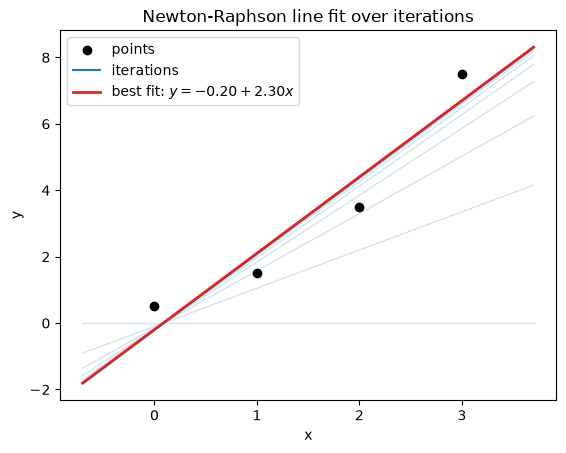

In [ ]:
xs = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)
x = np.array([p[0] for p in points], float)
y = np.array([p[1] for p in points], float)

plt.scatter(x, y, color="k", zorder=3, label="points")
for it in iterations:
    ci = it["c"]
    plt.plot(xs, ci[0] + ci[1] * xs, color="C0", lw=1, alpha=0.2)

plt.plot([], [], color="C0", label="iterations")

# best fit: the final iterate
cb = iterations[-1]["c"]
plt.plot(xs, cb[0] + cb[1] * xs, color="C3", lw=2,
        label=rf"best fit: $y = {cb[0]:.2f} + {cb[1]:.2f}x$")

plt.title("Newton-Raphson line fit over iterations")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.savefig("media/line_fit_newton.png", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
points = [(0, 0.5), (2, 3.5), (1, 1.5), (3, 7.5)]
x = np.array([p[0] for p in points], float)
y = np.array([p[1] for p in points], float)

def grad_E(c):
    return np.array([8 * c[0] + 12 * c[1] + 28 * c[2] - 26,
                     12 * c[0] + 28 * c[1] + 72 * c[2] - 62,
                     28 * c[0] + 72 * c[1] + 196 * c[2] - 166])

def hess_E(c):
    return np.array([[8, 12, 28],
                    [12, 28, 72],
                    [28, 72, 196]], float)

c, iterations = newton_raphson(grad_E, hess_E, c0=[0, 0, 0], delta=0.5)

for it in iterations:
    c = ", ".join(f"{v:.6f}" for v in it["c"])
    g = ", ".join(f"{v:.6f}" for v in it["grad"])
    print(f"c=({c})  grad=({g})")


c=(0.000000, 0.000000, 0.000000)  grad=(-26.000000, -62.000000, -166.000000)
c=(0.275000, 0.025000, 0.375000)  grad=(-13.000000, -31.000000, -83.000000)
c=(0.412500, 0.037500, 0.562500)  grad=(-6.500000, -15.500000, -41.500000)
c=(0.481250, 0.043750, 0.656250)  grad=(-3.250000, -7.750000, -20.750000)
c=(0.515625, 0.046875, 0.703125)  grad=(-1.625000, -3.875000, -10.375000)
c=(0.532812, 0.048438, 0.726562)  grad=(-0.812500, -1.937500, -5.187500)
c=(0.541406, 0.049219, 0.738281)  grad=(-0.406250, -0.968750, -2.593750)
c=(0.545703, 0.049609, 0.744141)  grad=(-0.203125, -0.484375, -1.296875)
c=(0.547852, 0.049805, 0.747070)  grad=(-0.101562, -0.242188, -0.648438)
c=(0.548926, 0.049902, 0.748535)  grad=(-0.050781, -0.121094, -0.324219)
c=(0.549463, 0.049951, 0.749268)  grad=(-0.025391, -0.060547, -0.162109)
c=(0.549731, 0.049976, 0.749634)  grad=(-0.012695, -0.030273, -0.081055)
c=(0.549866, 0.049988, 0.749817)  grad=(-0.006348, -0.015137, -0.040527)
c=(0.549933, 0.049994, 0.749908)  grad=(

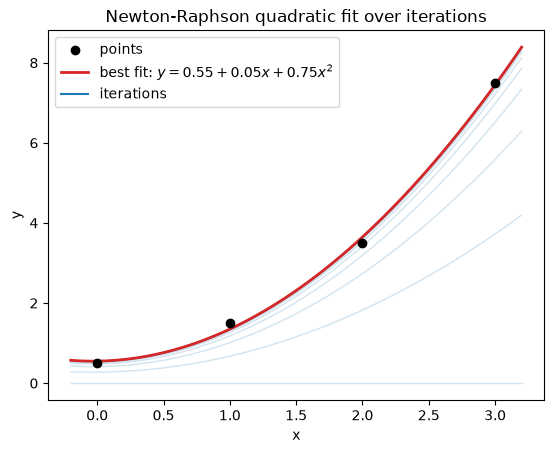

In [ ]:
xs = np.linspace(x.min() - 0.2, x.max() + 0.2, 100)

plt.scatter(x, y, color="k", zorder=3, label="points")
for it in iterations:
    ci = it["c"]
    plt.plot(xs, ci[0] + ci[1] * xs + ci[2] * xs**2, color="C0", lw=1, alpha=0.2)

cb = iterations[-1]["c"]
plt.plot(xs, cb[0] + cb[1] * xs + cb[2] * xs**2, color="C3", lw=2,
        label=rf"best fit: $y = {cb[0]:.2f} + {cb[1]:.2f}x + {cb[2]:.2f}x^2$")

plt.plot([], [], color="C0", label="iterations")
plt.title("Newton-Raphson quadratic fit over iterations")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()

plt.savefig(
    "media/quadratic_fit_newton.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()